Install packages

In [1]:
!pip install -q pandas hestia-good seaborn rdkit transformers accelerate datasets


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Download ChEMBL

In [ ]:
!wget -q https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz
!tar -xzf chembl_36_sqlite.tar.gz
!ls -lh chembl_36/chembl_36_sqlite/chembl_36.db

-rw-r--r-- 1 5012 1101 28G Sep 10  2025 chembl_36/chembl_36_sqlite/chembl_36.db


Query HCRTR1 data

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')
query = """
SELECT cs.canonical_smiles, act.pchembl_value, act.standard_type
FROM activities act
JOIN assays ass ON act.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.pref_name = 'Orexin/Hypocretin receptor type 1'
  AND act.standard_type IN ('IC50', 'Ki', 'Kd', 'EC50')
  AND act.pchembl_value IS NOT NULL
  AND ass.assay_type = 'B'
"""
df_raw = pd.read_sql(query, conn)
conn.close()
print(df_raw.shape)
df_raw.head()

(10258, 3)


,canonical_smiles,pchembl_value,standard_type
0,CO[C@@H]1CN(c2ncc(F)cn2)CC[C@@H]1[C@@H]1C[C@H]...,5.33,EC50
1,CCO[C@@H]1CN(c2ncc(Cl)cn2)CC[C@@H]1[C@@H]1C[C@...,5.85,EC50
2,C[C@H]1C[C@@H]([C@@H]2C[C@H]3CC[C@@H](C2)N3[C@...,5.41,EC50
3,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.16,IC50
4,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,5.28,IC50


Clean and deduplicate

In [3]:
df_clean = df_raw.groupby('canonical_smiles')['pchembl_value'].median().reset_index()
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(df_clean.shape)
df_clean.head()

(5989, 2)


,canonical_smiles,pchembl_value
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.75
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.00
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.00
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,7.31
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.30


Prepare dataframe

In [4]:
df = df_clean[['canonical_smiles', 'pchembl_value']].copy()
df = df.rename(columns={'canonical_smiles': 'Drug', 'pchembl_value': 'Y'})
print(df.shape)
df.head()

(5989, 2)


,Drug,Y
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.75
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.00
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.00
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,7.31
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.30


Scaffold-based split

In [5]:
from hestia.partition import ccpart, random_partition
from hestia.similarity import molecular_similarity

sim_df = molecular_similarity(
    df_query=df,
    fingerprint='ecfp',
    radius=2,
    bits=2048,
    df=df,
    field_name='Drug',
    verbose=3
)

train, test, clusters = ccpart(
    df=df,
    sim_df=sim_df,
    test_size=0.2,
    threshold=0.4,
)
train_df = df.iloc[train, :].copy().reset_index(drop=True)
test_df  = df.iloc[test,  :].copy().reset_index(drop=True)

train, val = random_partition(train_df, test_size=0.1, random_state=42)
val_df   = train_df.iloc[val,   :].copy().reset_index(drop=True)
train_df = train_df.iloc[train, :].copy().reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Calculating molecular similarities using ecfp with 2,048 bits, radius 2 and tanimoto index...


Query FPs: 100%|██████████| 5.99k/5.99k [00:00<00:00, 579kit/s]
Similarity calculation: 100%|██████████| 5.99k/5.99k [00:17<00:00, 347it/s]


Train: 5,094 | Val: 567 | Test: 328


Plot split distributions

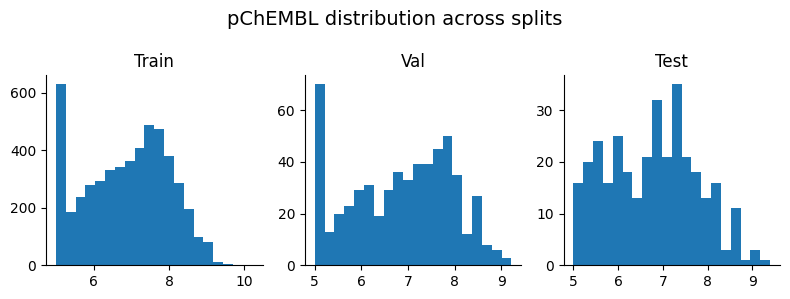

In [6]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 3, dpi=100)
fig.suptitle("pChEMBL distribution across splits", fontsize=14)
fig.set_size_inches(8, 3)
ax[0].hist(train_df['Y'], bins=20); ax[0].set_title('Train')
ax[1].hist(val_df['Y'],   bins=20); ax[1].set_title('Val')
ax[2].hist(test_df['Y'],  bins=20); ax[2].set_title('Test')
for i in range(3):
    ax[i].spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

Define metrics and custom trainer

In [7]:
from typing import Any, Callable, List

import numpy as np
import torch
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error
import transformers as hf


class CustomTrainer(hf.Trainer):
    def save_model(self, output_dir=None, _internal_call=False):
        device = self.model.device
        self.model = self.model.cpu()
        super().save_model(output_dir, _internal_call)
        self.model = self.model.to(device)


class Metrics:
    def __init__(self):
        self.metrics = {}

    def add_metric(self, name, metric):
        self.metrics[name] = metric

    def get_metrics(self, names):
        m = Metrics()
        for name in names:
            m.add_metric(name, self.metrics[name])
        return m

    def __call__(self, eval_prediction):
        output = {}
        preds = eval_prediction.predictions
        refs  = eval_prediction.label_ids
        if isinstance(preds, tuple):
            preds = preds[0]
        preds = preds.squeeze()
        for key, fn in self.metrics.items():
            output[key] = fn(preds, refs)[key]
        return output


def spcc(p, r, **kw): return {'spcc': float(spearmanr(r, p).correlation)}
def pcc(p, r, **kw):  return {'pcc':  float(pearsonr(r, p)[0])}
def mse(p, r, **kw):  return {'mse':  float(mean_squared_error(r, p))}
def mae(p, r, **kw):  return {'mae':  float(mean_absolute_error(r, p))}

metrics_collection = Metrics()
for name, fn in [('spcc', spcc), ('pcc', pcc), ('mse', mse), ('mae', mae)]:
    metrics_collection.add_metric(name, fn)

print("Metrics and CustomTrainer defined")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Metrics and CustomTrainer defined


Configure model

In [8]:
import copy
import transformers as hf
from datasets import Dataset

model_name = 'DeepChem/ChemBERTa-77M-MLM'
num_labels = 1
metrics    = ['pcc', 'spcc', 'mse', 'mae']

tokenizer = hf.AutoTokenizer.from_pretrained(model_name)
model     = hf.AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)

hf_args = hf.TrainingArguments(
    output_dir='chemberta_ft',
    learning_rate=2e-5,
    label_names=['labels'],
    metric_for_best_model='spcc',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=30,
    greater_is_better=True,
    eval_accumulation_steps=1,
    load_best_model_at_end=True,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    report_to='tensorboard',
)

ds = {
    'train': Dataset.from_pandas(train_df),
    'val':   Dataset.from_pandas(val_df),
    'test':  Dataset.from_pandas(test_df),
}

for split in ds.keys():
    ds[split] = ds[split].map(
        lambda x: tokenizer(x['Drug'], truncation=True, padding='max_length', max_length=128)
    )
    ds[split] = ds[split].rename_column('Y', 'labels')
    ds[split] = ds[split].map(lambda x: {'labels': float(x['labels'])})
    ds[split].set_format(type='pt', columns=['input_ids', 'attention_mask', 'labels'])

trainer = CustomTrainer(
    copy.deepcopy(model),
    args=hf_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    compute_metrics=metrics_collection.get_metrics(metrics),
    callbacks=[hf.EarlyStoppingCallback(early_stopping_patience=5)],
)
print("Trainer configured")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Map: 100%|██████████| 328/328 [00:00<00:00, 27733.17 examples/s]


Trainer configured


Train

In [9]:
values = trainer.train()
trainer._load_best_model()

  0%|          | 0/4800 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                  
  3%|▎         | 160/4800 [00:19<10:44,  7.20it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 21.21762466430664, 'eval_pcc': 0.3016467774422793, 'eval_spcc': 0.265330792500604, 'eval_mse': 21.217626571655273, 'eval_mae': 4.475584030151367, 'eval_runtime': 0.4997, 'eval_samples_per_second': 1134.635, 'eval_steps_per_second': 36.02, 'epoch': 1.0}


                                                  
  7%|▋         | 320/4800 [00:37<08:06,  9.21it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 5.668139934539795, 'eval_pcc': 0.33533372151065066, 'eval_spcc': 0.3516536815637158, 'eval_mse': 5.668139934539795, 'eval_mae': 2.1133644580841064, 'eval_runtime': 0.3764, 'eval_samples_per_second': 1506.349, 'eval_steps_per_second': 47.821, 'epoch': 2.0}


                                                  
 10%|█         | 480/4800 [00:54<07:57,  9.05it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

{'loss': 0.4524, 'grad_norm': 5.57351541519165, 'learning_rate': 1.25e-06, 'epoch': 28.12}


                                                   
 97%|█████████▋| 4640/4800 [09:16<00:17,  9.02it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4678475558757782, 'eval_pcc': 0.8180935561318847, 'eval_spcc': 0.7949886023091653, 'eval_mse': 0.4678474962711334, 'eval_mae': 0.5262814164161682, 'eval_runtime': 0.3926, 'eval_samples_per_second': 1444.254, 'eval_steps_per_second': 45.849, 'epoch': 29.0}


100%|█████████▉| 4799/4800 [09:33<00:00,  9.14it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                   
100%|██████████| 4800/4800 [09:34<00:00,  8.35it/s]

{'eval_loss': 0.46787014603614807, 'eval_pcc': 0.8181223077517643, 'eval_spcc': 0.7948560257741584, 'eval_mse': 0.4678701162338257, 'eval_mae': 0.5262385606765747, 'eval_runtime': 0.3819, 'eval_samples_per_second': 1484.717, 'eval_steps_per_second': 47.134, 'epoch': 30.0}
{'train_runtime': 574.5422, 'train_samples_per_second': 265.986, 'train_steps_per_second': 8.354, 'train_loss': 2.2425412877400714, 'epoch': 30.0}


Plot training and validation loss curves

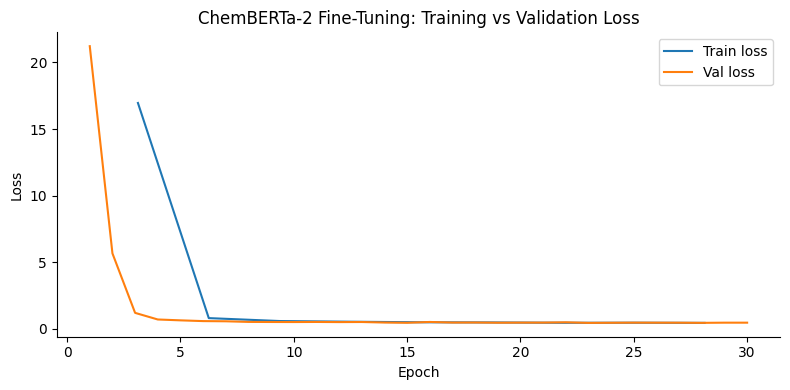

Best checkpoint: chemberta_ft/checkpoint-4640


In [10]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_loss = [(e['epoch'], e['loss'])      for e in log if 'loss' in e and 'eval_loss' not in e]
val_loss   = [(e['epoch'], e['eval_loss']) for e in log if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*zip(*train_loss), label='Train loss')
ax.plot(*zip(*val_loss),   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('ChemBERTa-2 Fine-Tuning: Training vs Validation Loss')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chemberta_loss_curves.png', dpi=150)
plt.show()
print(f'Best checkpoint: {trainer.state.best_model_checkpoint}')

Evaluate on test set

In [11]:
metrics_out = trainer.evaluate(eval_dataset=ds['test'], metric_key_prefix='test')
met_df = pd.DataFrame([metrics_out])
met_df.head()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 11/11 [00:00<00:00, 40.77it/s]


,test_loss,test_pcc,test_spcc,test_mse,test_mae,test_runtime,test_samples_per_second,test_steps_per_second,epoch
0,1.319963,0.097706,0.090484,1.319963,0.924932,0.3765,871.126,29.215,30.0


Scatterplot: predicted vs ground truth

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 18/18 [00:00<00:00, 49.25it/s]
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 11/11 [00:00<00:00, 46.43it/s]


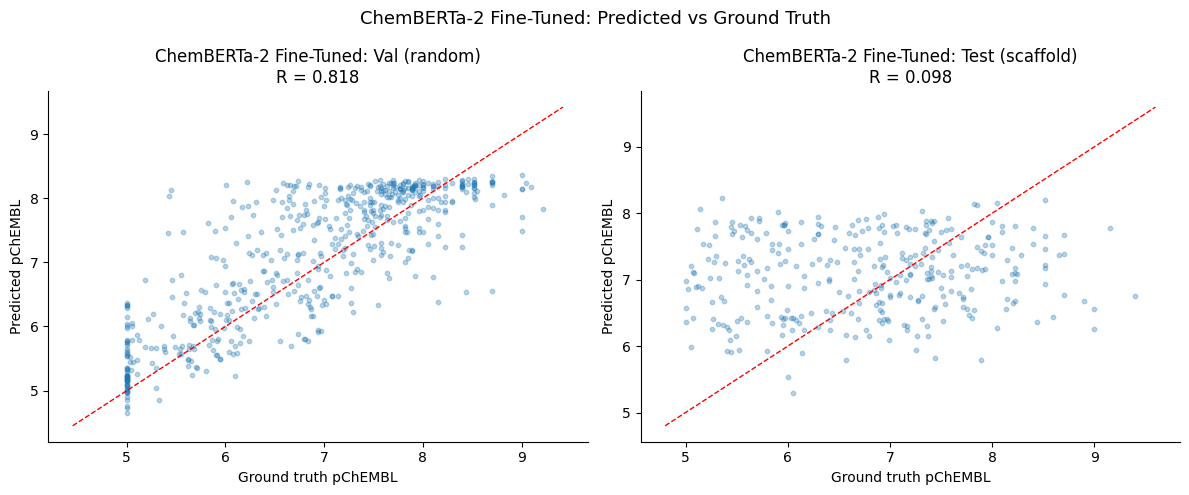

Val R = 0.818 | Test R = 0.098


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def get_preds(split):
    out = trainer.predict(ds[split])
    return out.predictions.squeeze(), out.label_ids

y_pred_val,  y_true_val  = get_preds('val')
y_pred_test, y_true_test = get_preds('test')

from scipy.stats import pearsonr
r_val,  _ = pearsonr(y_true_val,  y_pred_val)
r_test, _ = pearsonr(y_true_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, label, r in [
    (axes[0], y_true_val,  y_pred_val,  'Val (random)',   r_val),
    (axes[1], y_true_test, y_pred_test, 'Test (scaffold)', r_test),
]:
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    lims = [min(y_true.min(), y_pred.min()) - 0.2,
            max(y_true.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Ground truth pChEMBL')
    ax.set_ylabel('Predicted pChEMBL')
    ax.set_title(f'ChemBERTa-2 Fine-Tuned: {label}\nR = {r:.3f}')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('ChemBERTa-2 Fine-Tuned: Predicted vs Ground Truth', fontsize=13)
plt.tight_layout()
plt.savefig('chemberta_ft_scatter.png', dpi=150)
plt.show()
print(f'Val R = {r_val:.3f} | Test R = {r_test:.3f}')

Configuration log

In [13]:
import pandas as pd

config = {
    'model': model_name,
    'num_params': sum(p.numel() for p in model.parameters()),
    'task': 'regression (pChEMBL)',
    'learning_rate': hf_args.learning_rate,
    'batch_size': hf_args.per_device_train_batch_size,
    'max_epochs': hf_args.num_train_epochs,
    'early_stopping_patience': 5,
    'max_length': 128,
    'split': 'scaffold (hestia ccpart, Tanimoto 0.4)',
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'best_checkpoint': trainer.state.best_model_checkpoint,
}
pd.DataFrame([config]).T

,0
model,DeepChem/ChemBERTa-77M-MLM
num_params,3427825
task,regression (pChEMBL)
learning_rate,0.00002
batch_size,32
max_epochs,30
early_stopping_patience,5
max_length,128
split,"scaffold (hestia ccpart, Tanimoto 0.4)"
train_size,5094
